In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import re
import matplotlib.patches as mpatches
import shap
import os
import warnings
import logging
warnings.filterwarnings("ignore")
logging.basicConfig(level = logging.INFO, format = "%(message)s")
log = logging.getLogger(__name__)

/home/tiffany/tf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dir = os.path.join("..", "Data")
seed = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cameras = {
    "Boquillas": 8,
    "CharlestonMesquite": 2,
    "Contention": 6,
    "Fairbank": 1,
    "Hereford": 5,
    "Hunter": 4,
    "Moson": 3,
    "St.David": 7,
}
camera_sites = set(cameras.keys())

target = "fp"
predictors = ["camera", "prcp", "vpd", "tmax", "tmin", "dtgw", "et"]
test_frac = 0.2

params_path = os.path.join(dir, "Params.csv")
params = pd.read_csv(params_path)
if params.empty:
    raise ValueError(f"No rows found in {params_path}")
params = params.iloc[0].to_dict()

seq_len = int(params["seq_len"])
hidden_size = int(params["hidden_size"])
num_layers = int(params["num_layers"])
dropout = float(params["dropout"])
lr = float(params["lr"])
batch_size = int(params["batch_size"])

seq_len, hidden_size, num_layers, dropout, lr, batch_size

(30, 128, 3, 0.1, 0.0006288316298309, 32)

In [ ]:
def load_climate():
    path = os.path.join(dir, "Daymet2006_2025.csv")
    climate = pd.read_csv(path)
    climate.columns = climate.columns.str.strip().str.lower()
    climate["date"] = pd.to_datetime(climate["date"], format = "mixed")
    climate = climate.rename(columns = {"tvpd": "vpd"})
    col = ["site", "camera", "date", "prcp", "vpd", "tmax", "tmin"]
    return climate[col].copy()

def load_et():
    path = os.path.join(dir, "Jawad_ET", "J.csv")
    et = pd.read_csv(path)
    et.columns = et.columns.str.strip().str.lower()
    et["date"] = pd.to_datetime(et["date"], format = "mixed")
    return et[["site", "camera", "date", "et"]].copy()

def load_fp():
    path = os.path.join(dir, "USPPFlowMonitoring2006_2025.csv")
    flow = pd.read_csv(path)
    flow.columns = flow.columns.str.strip().str.lower()
    flow["date"] = pd.to_datetime(flow["date"], format = "mixed")
    flow = flow.rename(columns = {"flow code": "fc"})
    flow["fc"] = pd.to_numeric(flow["fc"], errors = "coerce")
    flow[target] = np.where(flow["fc"].isna(), np.nan, (flow["fc"] > 0).astype(int))
    return flow.groupby(["site", "date"], as_index = False)[target].max()

def load_gw():
    path = os.path.join(dir, "GW/CamShallowGW2006_2025.csv")
    gw = pd.read_csv(path)
    gw.columns = gw.columns.str.strip().str.lower()
    gw["date"] = pd.to_datetime(gw["date"], format = "mixed")
    gw["dtgw"] = pd.to_numeric(gw["dtgw"], errors = "coerce")
    return gw.groupby(["site", "camera", "date"])["dtgw"].mean().reset_index()

def merge_all():
    climate = load_climate()
    et = load_et()
    fp = load_fp()
    gw = load_gw()

    hydro = climate.merge(fp[["site", "date", target]], on = ["site", "date"], how = "right")
    hydro = hydro.merge(et[["site", "date", "et"]], on = ["site", "date"], how = "left")
    hydro = hydro.merge(gw[["site", "date", "dtgw"]], on = ["site", "date"], how = "left")
    hydro = hydro.sort_values(["site", "date"])
    hydro["dtgw"] = (
        hydro.groupby("site")["dtgw"]
        .transform(lambda s: s.interpolate(method = "linear", limit_direction = "both"))
    )
    hydro["year"] = hydro["date"].dt.year
    hydro["camera"] = hydro["site"].map(cameras)
    hydro = hydro[hydro["site"].isin(camera_sites)].copy()
    return hydro

In [13]:
class HydroDataset(Dataset):
    def __init__(self, sequences, labels):
        self.x = torch.FloatTensor(sequences)
        self.y = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

def build_feature_sequences(df, features, seq_len, sites):
    sequences, labels, meta = [], [], []
    for site in sites:
        sdata = df[df["site"] == site].sort_values("date").reset_index(drop = True)
        x_vals = sdata[features].values
        y_vals = sdata[target].values
        dates = sdata["date"].values

        for i in range(seq_len, len(sdata)):
            seq = x_vals[i - seq_len:i]
            y_val = y_vals[i]
            if np.isnan(seq).any() or np.isnan(y_val):
                continue
            sequences.append(seq)
            labels.append(y_val)
            meta.append({"site": site, "date": dates[i]})

    return np.array(sequences), np.array(labels), meta

def build_split_sequences(df, features, seq_len, sites, train_flag, val_flag, label):
    train_sequences, train_labels = [], []
    val_sequences, val_labels = [], []
    train_meta, val_meta = [], []

    for site in sites:
        sdata = df[df["site"] == site].sort_values("date").reset_index(drop = True)
        x_vals = sdata[features].values
        y_vals = sdata[label].values
        dates = sdata["date"].values
        is_train = sdata[train_flag].values
        is_val = sdata[val_flag].values

        for i in range(seq_len, len(sdata)):
            seq = x_vals[i - seq_len:i]
            y_val = y_vals[i]
            if np.isnan(seq).any() or np.isnan(y_val):
                continue

            if is_train[i]:
                train_sequences.append(seq)
                train_labels.append(y_val)
                train_meta.append({"site": site, "date": dates[i]})
            elif is_val[i]:
                val_sequences.append(seq)
                val_labels.append(y_val)
                val_meta.append({"site": site, "date": dates[i]})

    if len(train_sequences) == 0:
        train_sequences = np.empty((0, seq_len, len(features)))
        train_labels = np.empty((0,))
    else:
        train_sequences = np.array(train_sequences)
        train_labels = np.array(train_labels)

    if len(val_sequences) == 0:
        val_sequences = np.empty((0, seq_len, len(features)))
        val_labels = np.empty((0,))
    else:
        val_sequences = np.array(val_sequences)
        val_labels = np.array(val_labels)

    return train_sequences, train_labels, train_meta, val_sequences, val_labels, val_meta

def build_prediction_sequences(df, features, seq_len, sites):
    sequences, meta = [], []
    for site in sites:
        sdata = df[df["site"] == site].sort_values("date").reset_index(drop = True)
        x_vals = sdata[features].values
        y_vals = sdata[target].values
        dates = sdata["date"].values

        for i in range(seq_len, len(sdata)):
            if not np.isnan(y_vals[i]):
                continue
            seq = x_vals[i - seq_len:i]
            if np.isnan(seq).any():
                continue
            sequences.append(seq)
            meta.append({"site": site, "date": dates[i]})

    if len(sequences) == 0:
        return np.empty((0, seq_len, len(features))), meta
    return np.array(sequences), meta

In [26]:
class BiLSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            bidirectional = True,
            dropout = dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out.squeeze(-1)

def train_model(model, train_loader, val_loader, lr, epochs, patience = 10, use_early_stopping = True):
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)
    criterion = nn.MSELoss()

    best_rmse = np.inf
    best_state = None
    wait = 0

    for _ in range(epochs):
        model.train()
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

        if val_loader is None or not use_early_stopping:
            continue

        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                preds = model(x_batch).cpu().numpy()
                val_preds.extend(preds)
                val_true.extend(y_batch.numpy())

        val_rmse = np.sqrt(mean_squared_error(val_true, val_preds))
        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if use_early_stopping and val_loader is not None and best_state is not None:
        model.load_state_dict(best_state)
    return model, best_rmse

def evaluate_on_test(model, test_loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(y_batch.numpy())
    return np.array(all_true), np.array(all_preds)

def predict_missing(model, pred_loader):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for x_batch in pred_loader:
            if isinstance(x_batch, (list, tuple)):
                x_batch = x_batch[0]
            x_batch = x_batch.to(device)
            preds = model(x_batch).cpu().numpy()
            all_preds.extend(preds)
    return np.array(all_preds)

def permutation_importance_lstm(model, x_test, y_test, feature_names, n_repeats = 8, random_state = 1):
    rng = np.random.default_rng(random_state)
    model.eval()

    with torch.no_grad():
        base_preds = model(torch.FloatTensor(x_test).to(device)).cpu().numpy()
    base_rmse = np.sqrt(mean_squared_error(y_test, base_preds))

    scores = []
    for j, feat in enumerate(feature_names):
        rmse_deltas = []
        for _ in range(n_repeats):
            x_perm = x_test.copy()
            idx = rng.permutation(x_perm.shape[0])
            x_perm[:, :, j] = x_perm[idx, :, j]
            with torch.no_grad():
                perm_preds = model(torch.FloatTensor(x_perm).to(device)).cpu().numpy()
            perm_rmse = np.sqrt(mean_squared_error(y_test, perm_preds))
            rmse_deltas.append(perm_rmse - base_rmse)

        scores.append({
            "feature": feat,
            "importance_mean": float(np.mean(rmse_deltas)),
            "importance_std": float(np.std(rmse_deltas)),
        })

    result = pd.DataFrame(scores).sort_values("importance_mean", ascending = False).reset_index(drop = True)
    return result

def shap_lstm_importance(model, x_background, x_explain, feature_names):
    class _ShapModelWrapper(nn.Module):
        def __init__(self, base_model):
            super().__init__()
            self.base_model = base_model

        def forward(self, x):
            out = self.base_model(x)
            if out.ndim == 1:
                out = out.unsqueeze(-1)
            return out

    model.eval()
    wrapped_model = _ShapModelWrapper(model).to(device)
    wrapped_model.eval()

    background_t = torch.FloatTensor(x_background).to(device)
    explain_t = torch.FloatTensor(x_explain).to(device)

    explainer = shap.DeepExplainer(wrapped_model, background_t)
    shap_values = explainer.shap_values(explain_t, check_additivity = False)

    if isinstance(shap_values, list):
        shap_arr = np.array(shap_values[0])
    else:
        shap_arr = np.array(shap_values)

    if shap_arr.ndim == 4 and shap_arr.shape[-1] == 1:
        shap_arr = shap_arr[:, :, :, 0]

    mean_abs_by_feature = np.abs(shap_arr).mean(axis = (0, 1))
    shap_df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_by_feature,
    }).sort_values("mean_abs_shap", ascending = False).reset_index(drop = True)
    return shap_df, shap_arr

In [16]:
hydro = merge_all()
features = predictors.copy()

hydro = hydro.dropna(subset = features, how = "all")

hydro["fp_obs"] = hydro[target]
observed_pool = hydro["fp_obs"].notna() & hydro["site"].isin(camera_sites)
obs_idx = hydro.index[observed_pool].to_numpy()
n_test = int(len(obs_idx) * test_frac)

rng = np.random.default_rng(seed)
hydro["is_test_mask"] = False
if n_test > 0:
    test_idx = rng.choice(obs_idx, size = n_test, replace = False)
    hydro.loc[test_idx, "is_test_mask"] = True

hydro["is_fit"] = hydro["fp_obs"].notna() & (~hydro["is_test_mask"])

train_mask = hydro["is_fit"]
for feat in features:
    n_missing = hydro[feat].isna().sum()
    if n_missing > 0:
        fill_val = hydro.loc[train_mask, feat].median()
        hydro[feat] = hydro[feat].fillna(fill_val)

fit = hydro[hydro["is_fit"]].copy()
scaler = StandardScaler()
scaler.fit(fit[features])

hydro_scaled = hydro.copy()
hydro_scaled[features] = scaler.transform(hydro_scaled[features])

train_seqs, train_labels, train_meta, test_seqs, test_labels, test_meta = build_split_sequences(
    hydro_scaled,
    features,
    seq_len,
    camera_sites,
    train_flag = "is_fit",
    val_flag = "is_test_mask",
    label = "fp_obs",
)

train_loader = DataLoader(HydroDataset(train_seqs, train_labels), batch_size = batch_size, shuffle = True)
test_loader = DataLoader(HydroDataset(test_seqs, test_labels), batch_size = batch_size)

torch.manual_seed(seed)
np.random.seed(seed)

model = BiLSTMRegressor(
    input_size = len(features),
    hidden_size = hidden_size,
    num_layers = num_layers,
    dropout = dropout
).to(device)

model, _ = train_model(model, train_loader, None, lr, epochs = 100, patience = 15, use_early_stopping = False)
y_true, y_pred = evaluate_on_test(model, test_loader)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"Untouched test-mask points: {int(hydro['is_test_mask'].sum())}")
print(f"Evaluation sequences: {len(test_seqs)}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")

Untouched test-mask points: 9157
Evaluation sequences: 9157
RMSE: 0.1126
MAE:  0.0237
R^2:  0.9131


In [17]:
hydro_final = hydro_scaled.copy()
hydro_final[target] = hydro_final["fp_obs"]

all_seqs, all_labels, _ = build_feature_sequences(hydro_final, features, seq_len, camera_sites)
all_loader = DataLoader(HydroDataset(all_seqs, all_labels), batch_size = batch_size, shuffle = True)

final_model = BiLSTMRegressor(
    input_size = len(features),
    hidden_size = hidden_size,
    num_layers = num_layers,
    dropout = dropout
).to(device)

final_model, _ = train_model(final_model, all_loader, all_loader, lr, epochs = 100, patience = 15)

pred_target = hydro_final.copy()
pred_target[target] = pred_target["fp_obs"]
pred_target.loc[pred_target["fp_obs"].notna(), target] = pred_target["fp_obs"]

pred_seqs, pred_meta = build_prediction_sequences(pred_target, features, seq_len, camera_sites)

if len(pred_seqs) > 0:
    pred_dataset = torch.FloatTensor(pred_seqs)
    pred_loader = DataLoader(pred_dataset, batch_size = batch_size)
    preds = predict_missing(final_model, pred_loader)
    preds = np.clip(np.rint(preds), 0, 1).astype(int)

    pred = pd.DataFrame(pred_meta)
    pred[f"{target}_pred"] = preds
    pred["date"] = pd.to_datetime(pred["date"])
else:
    pred = pd.DataFrame(columns = ["site", "date", f"{target}_pred"])

out = hydro_final[["site", "camera", "date", "prcp", "vpd", "tmax", "tmin", "dtgw", "et", "fp_obs", "is_test_mask"]].copy()
out = out.rename(columns = {"fp_obs": target})
out = out.merge(pred[["site", "date", f"{target}_pred"]], on = ["site", "date"], how = "left")
out[f"{target}_final"] = out[target].fillna(out[f"{target}_pred"]).astype("Int64")
out["source"] = out[target].apply(lambda x: "observed" if pd.notna(x) else "predicted")
out.loc[out[target].isna() & out[f"{target}_pred"].notna(), "source"] = "predicted"

pred_out_path = os.path.join(dir, "InterPredFP.csv")
out.to_csv(pred_out_path, index = False)

pred_out_path, len(out), int((out["source"] == "predicted").sum())

('../Data/InterPredFP.csv', 54958, 9169)

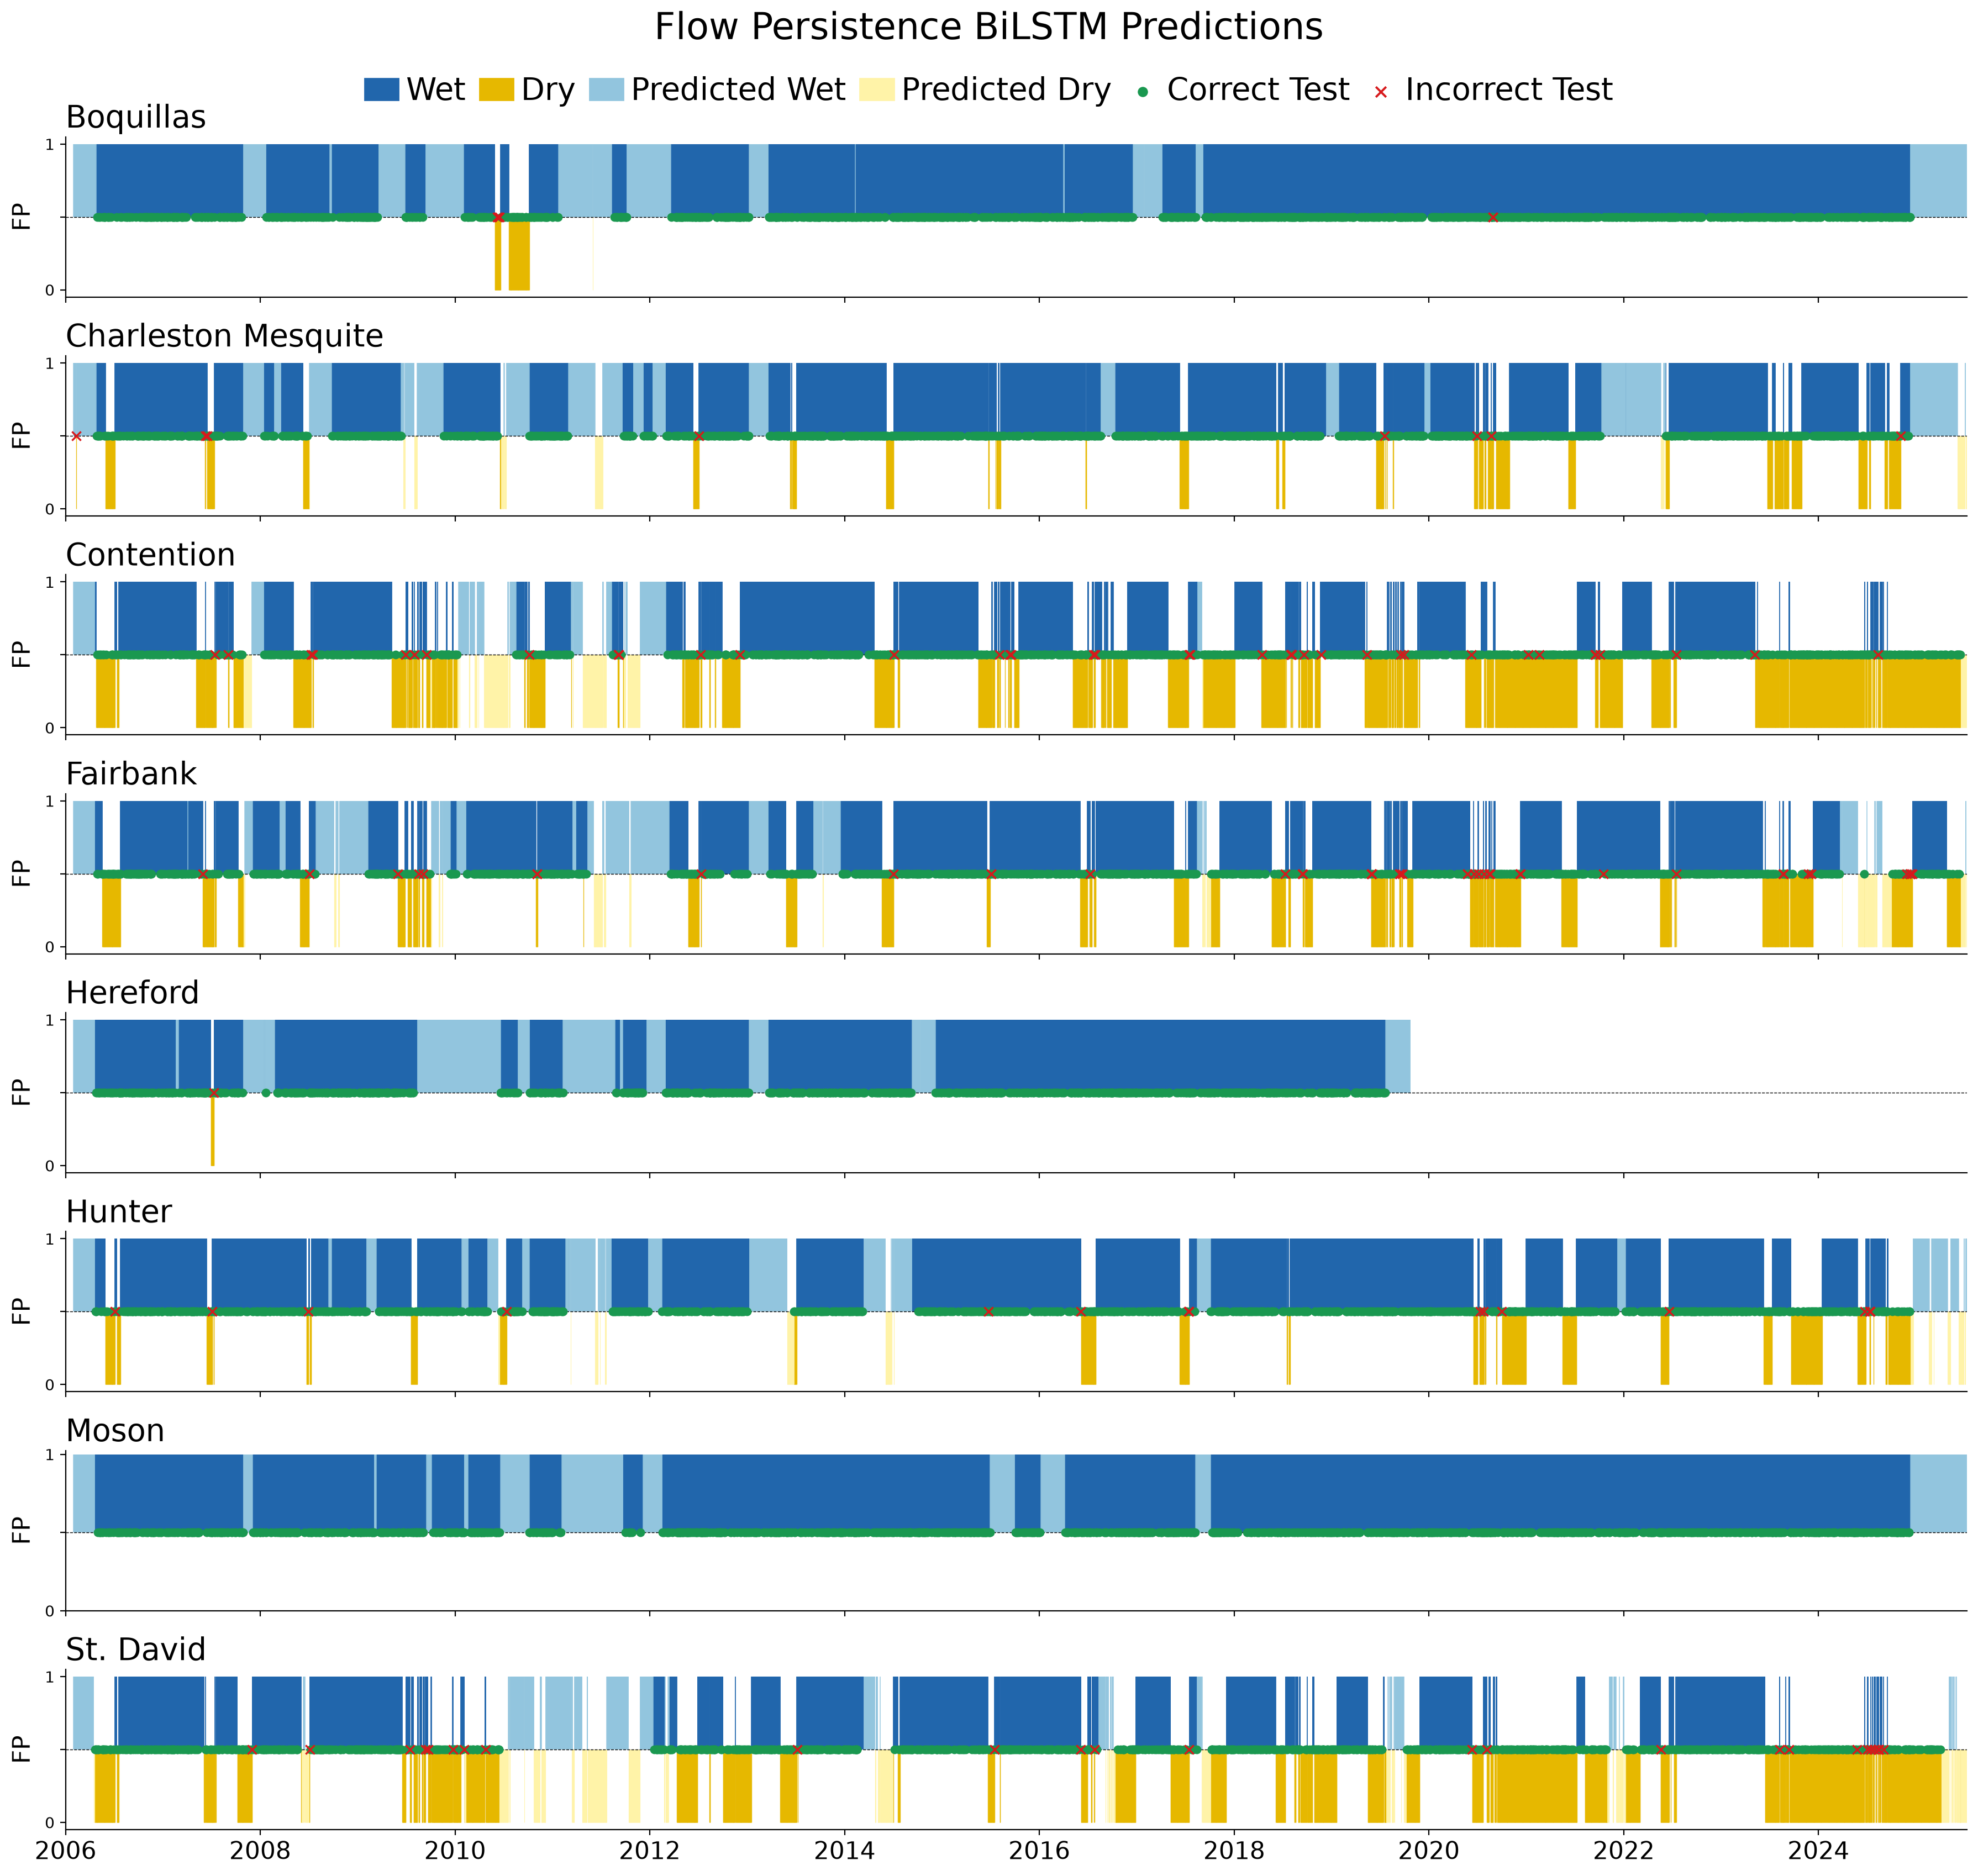

In [19]:
import re
import matplotlib.patches as mpatches

test_pred = pd.DataFrame(test_meta)
test_pred["date"] = pd.to_datetime(test_pred["date"])
test_pred["fp_test_pred"] = y_pred

plot_df = out.merge(test_pred[["site", "date", "fp_test_pred"]], on = ["site", "date"], how = "left")
plot_df["date"] = pd.to_datetime(plot_df["date"])

sites_sorted = sorted(camera_sites)
fig, axes = plt.subplots(len(sites_sorted), 1, figsize = (18, 2.2 * len(sites_sorted)), sharex = True)
if len(sites_sorted) == 1:
    axes = [axes]

for idx, site in enumerate(sites_sorted):
    ax = axes[idx]
    sdata = plot_df[plot_df["site"] == site].sort_values("date")

    obs = sdata[sdata["source"] == "observed"]
    pred = sdata[sdata["source"] == "predicted"]

    obs_flow = obs[obs[target] == 1]
    obs_noflow = obs[obs[target] == 0]
    ax.vlines(obs_flow["date"], 0, 1, colors = "#2166ac", linewidth = 0.7, alpha = 0.9)
    ax.vlines(obs_noflow["date"], 0, -1, colors = "#e6b800", linewidth = 0.5, alpha = 0.9)

    pred_flow = pred[pred[f"{target}_pred"] == 1]
    pred_noflow = pred[pred[f"{target}_pred"] == 0]
    ax.vlines(pred_flow["date"], 0, 1, colors = "#92c5de", linewidth = 0.55, alpha = 0.9)
    ax.vlines(pred_noflow["date"], 0, -1, colors = "#fff3a8", linewidth = 0.4, alpha = 0.9)

    test = sdata[sdata["fp_test_pred"].notna()].copy()
    test["pred_bin"] = (test["fp_test_pred"] > 0.5).astype(int)
    test["correct"] = test["pred_bin"] == test[target].astype(int)

    ax.scatter(
        test[test["correct"]]["date"],
        [0] * test["correct"].sum(),
        color = "#1a9850",
        s = 22,
        zorder = 5,
        marker = "o"
    )
    ax.scatter(
        test[~test["correct"]]["date"],
        [0] * (~test["correct"]).sum(),
        color = "#d7191c",
        s = 34,
        zorder = 6,
        marker = "x",
        linewidths = 1.2
    )

    ax.axhline(0, color = "black", linewidth = 0.5, linestyle = "--")
    ax.set_yticklabels(["0", "", "1"])
    ax.set_yticks([-1, 0, 1])
    ax.set_ylabel("FP", fontsize = 16, labelpad = 6)
    formatted_site = re.sub(r"(?<=[a-z\.])(?=[A-Z])", " ", site)
    ax.set_title(formatted_site, fontsize = 20, fontweight = "normal", loc = "left")
    ax.set_xlim(sdata["date"].min(), sdata["date"].max())
    ax.tick_params(axis = "x", labelsize = 16)
    ax.spines[["top", "right"]].set_visible(False)

legend_handles = [
    mpatches.Patch(color = "#2166ac", label = "Wet"),
    mpatches.Patch(color = "#e6b800", label = "Dry"),
    mpatches.Patch(color = "#92c5de", label = "Predicted Wet"),
    mpatches.Patch(color = "#fff3a8", label = "Predicted Dry"),
    plt.scatter([], [], color = "#1a9850", s = 32, marker = "o", label = "Correct Test"),
    plt.scatter([], [], color = "#d7191c", s = 45, marker = "x", linewidths = 1.4, label = "Incorrect Test"),
]
fig.legend(
    handles = legend_handles,
    loc = "upper center",
    ncol = 6,
    fontsize = 20,
    bbox_to_anchor = (0.5, 0.96),
    frameon = False,
    borderpad = 0.08,
    borderaxespad = 0.02,
    handletextpad = 0.25,
    columnspacing = 0.45,
    handlelength = 1.1
)

plt.suptitle("Flow Persistence BiLSTM Predictions", fontsize = 24, y = 0.992)
plt.tight_layout(rect = [0, 0.03, 1, 0.98])

%config InlineBackend.figure_format = "retina"

# plt.savefig("../Figures/inter_bilstm_ts.png", format = "png", dpi = 300, bbox_inches = "tight")

,feature,importance_mean,importance_std
0,camera,0.306243,0.002528
1,tmin,0.243556,0.002480
2,dtgw,0.239401,0.002776
3,vpd,0.220591,0.003359
4,tmax,0.219168,0.003760
5,et,0.201590,0.003871
6,prcp,0.181382,0.002138


'../Data/FeatureImportancePermutation.csv'

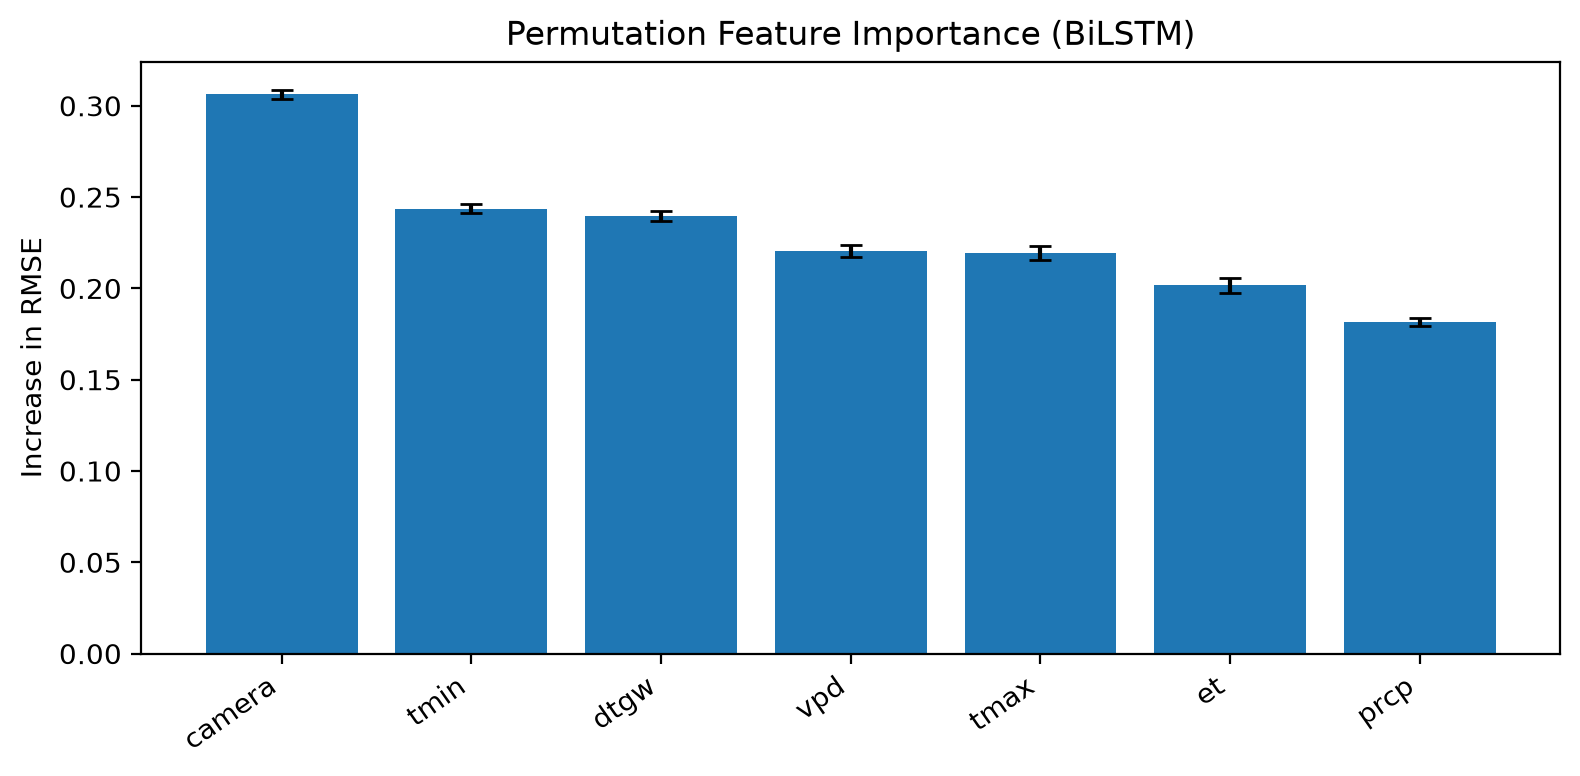

In [20]:
perm = permutation_importance_lstm(
    model = model,
    x_test = test_seqs,
    y_test = test_labels,
    feature_names = features,
    n_repeats = 10,
    random_state = seed,
)

perm_out_path = os.path.join(dir, "FeatureImportancePermutation.csv")
perm.to_csv(perm_out_path, index = False)

display(perm)

plt.figure(figsize = (8, 4))
plt.bar(perm["feature"], perm["importance_mean"], yerr = perm["importance_std"], capsize = 4)
plt.xticks(rotation = 35, ha = "right")
plt.ylabel("Increase in RMSE")
plt.title("Permutation Feature Importance (BiLSTM)")
plt.tight_layout()
perm_out_path

,feature,mean_abs_shap
0,tmin,0.002494
1,et,0.002054
2,prcp,0.001434
3,vpd,0.001256
4,camera,0.001150
5,dtgw,0.001126
6,tmax,0.000975


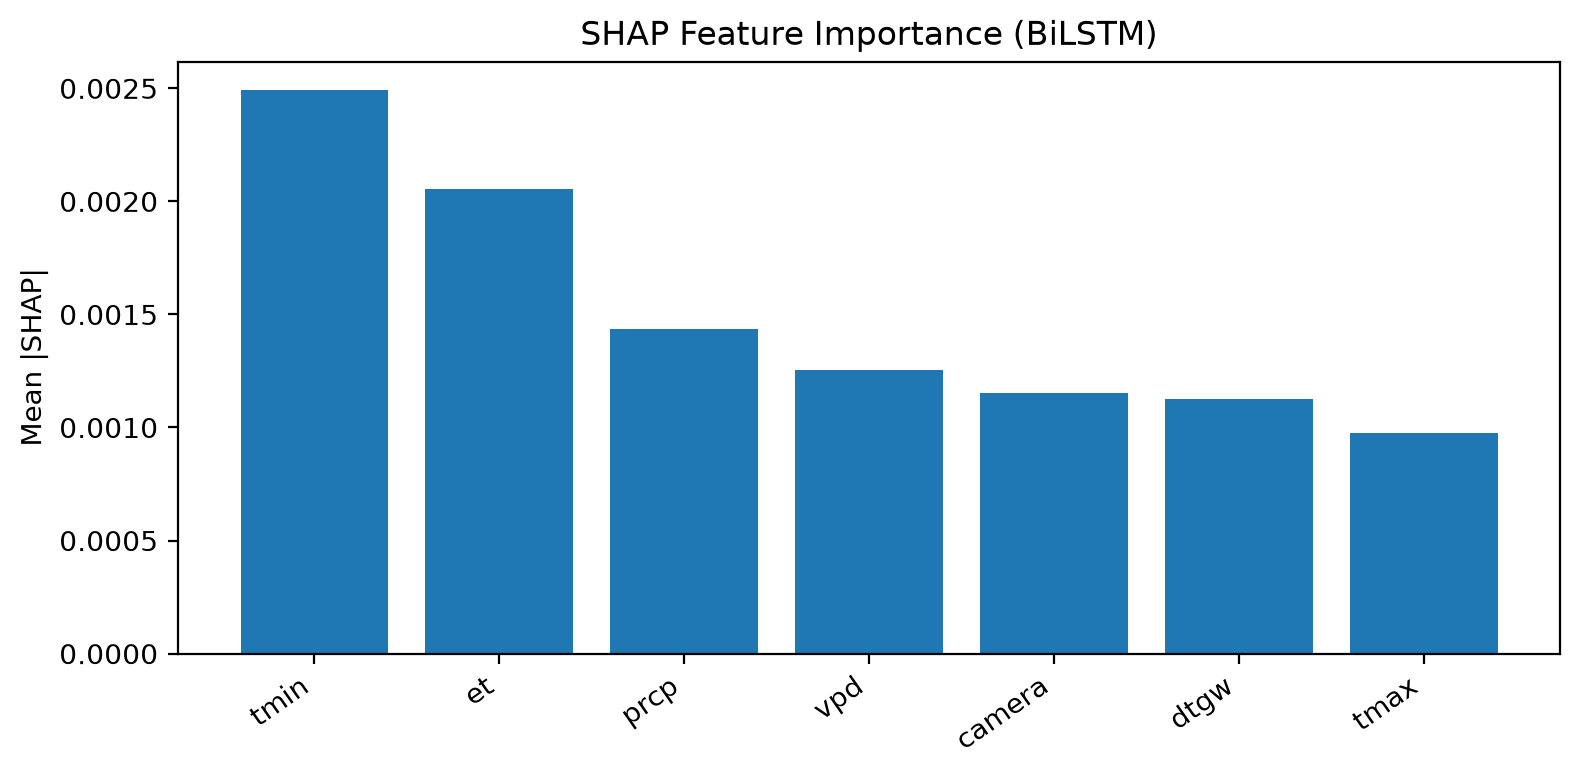

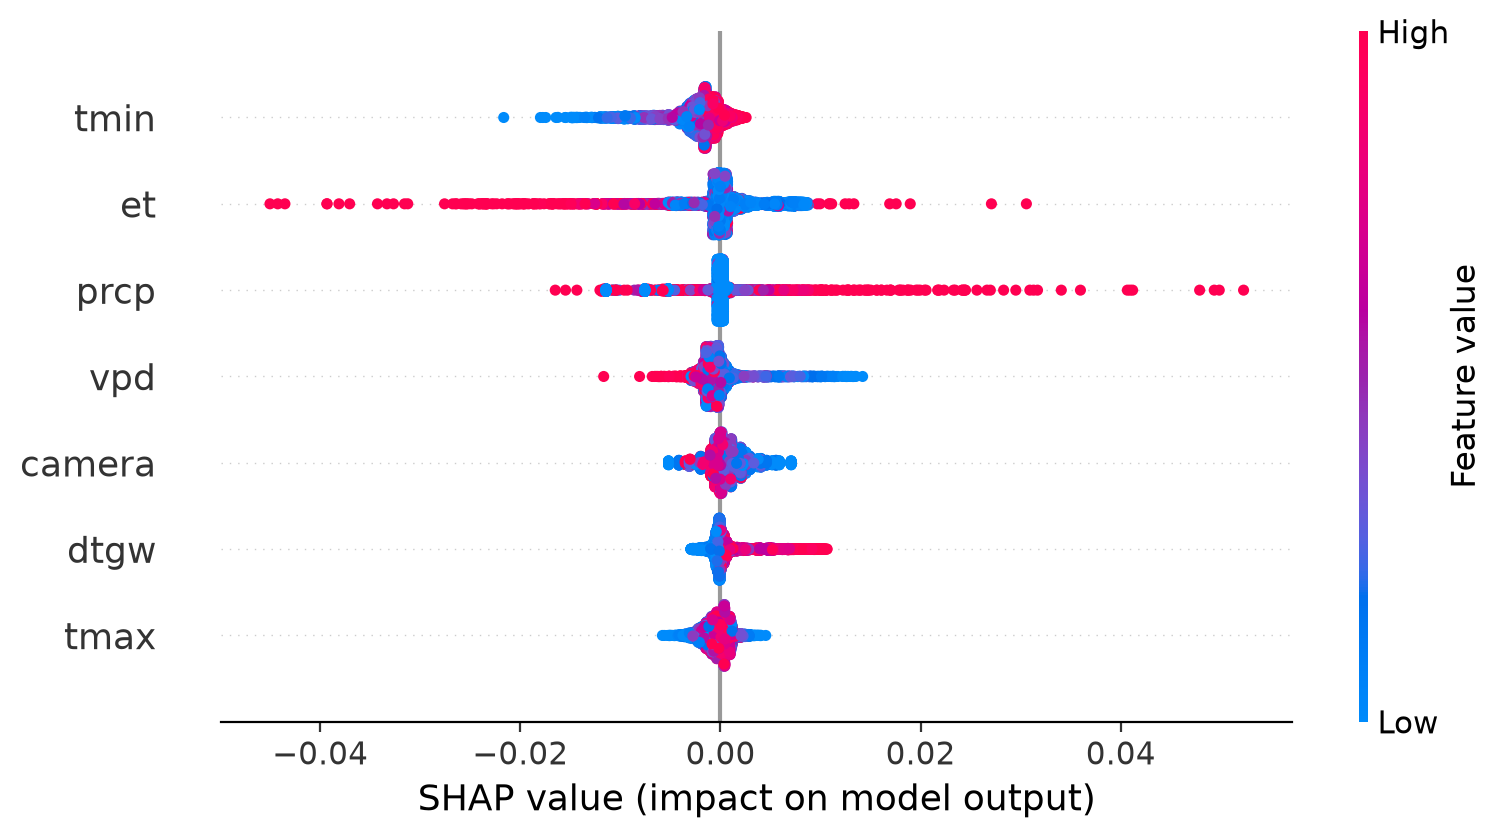

'../Data/FeatureImportanceSHAP.csv'

In [ ]:
if len(test_seqs) == 0:
    raise ValueError("No test sequences available for SHAP.")

bg_n = min(200, len(train_seqs))
ex_n = min(200, len(test_seqs))

bg_idx = np.random.default_rng(seed).choice(len(train_seqs), size = bg_n, replace = False)
ex_idx = np.random.default_rng(seed + 1).choice(len(test_seqs), size = ex_n, replace = False)

x_background = train_seqs[bg_idx]
x_explain = test_seqs[ex_idx]

shap_df, shap_arr = shap_lstm_importance(model, x_background, x_explain, features)

shap_out_path = os.path.join(dir, "FeatureImportanceSHAP.csv")
shap_df.to_csv(shap_out_path, index = False)

display(shap_df)

plt.figure(figsize = (8, 4))
plt.bar(shap_df["feature"], shap_df["mean_abs_shap"])
plt.xticks(rotation = 35, ha = "right")
plt.ylabel("Mean |SHAP|")
plt.title("BiLSTM SHAP Feature Importance")
plt.tight_layout()
plt.show()

if shap_arr.ndim == 3:
    shap_values_plot = shap_arr.reshape(-1, shap_arr.shape[-1])
    x_explain_plot = x_explain.reshape(-1, x_explain.shape[-1])
elif shap_arr.ndim == 2:
    shap_values_plot = shap_arr
    x_explain_plot = x_explain if x_explain.ndim == 2 else x_explain.reshape(-1, x_explain.shape[-1])
else:
    raise ValueError(f"Unexpected SHAP array shape: {shap_arr.shape}")

plt.figure(figsize = (10, 5))
shap.summary_plot(shap_values_plot, x_explain_plot, feature_names = features, show = False, max_display = len(features))
plt.tight_layout()
plt.show()

shap_out_path

In [31]:
import dill
dill.dump_session("../Data/FI.pkl")